# 08 · Coincident frequency

Propagate fitted paired distributions through an explicitly specified response grid.
The first three cases use Z = X + Y, then a Waimea/Makaweli conditional flood-response
surface. Restart Kernel and Run All constructs and executes the analyses from raw inputs.
API reference: `CoincidentFrequencyAnalysisTests.cs` constructs the bivariate parent,
two-dimensional response, CFA analysis, and checks the Normal-sum AEP.

In [2]:
from pathlib import Path
import sys, json, hashlib
ROOT = Path.cwd() if (Path.cwd() / "runtime-lock.json").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
from time import perf_counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from bestfit_examples.runtime import load_bestfit
from bestfit_examples.raw import load_raw, net_matrix
from bestfit_examples.fresh import plot_context, plots, show, record_run
runtime = load_bestfit()
print(runtime)
from System import Array, Double, DateTime, Object
from System.Collections.Generic import List
from Numerics.Distributions import UnivariateDistributionType, Normal, Uniform, LogNormal
from Numerics.Distributions.Copulas import CopulaType
from RMC.BestFit.Models import (DataFrame, ExactData, ExactSeries, ThresholdData,
    UnivariateDistribution, BivariateDistribution, QuantilePrior)
from RMC.BestFit.Analyses import UnivariateAnalysis, BivariateAnalysis, CoincidentFrequencyAnalysis
from RMC.BestFit.Estimation import BayesianAnalysis

{'schemaVersion': 1, 'sourceCommit': 'db5807d6e3a85606797cda79542f2d51a80a57a6', 'numericsVersion': '2.2.0.0', 'bestFitVersion': '2.0.0.0', 'targetFramework': '.NETCoreApp,Version=v10.0', 'fileHashes': {'RMC.BestFit.dll': '8714d7e4e9d738e99e45c36d5581ce759e8fd535361b7a141d9647a9a5eac8dd', 'Numerics.dll': '364d2296a6024643a8bf0f60d1eaa8f5be5511563dea0b5d572074e45c27ea48'}}


## Load observations and authored response inputs

`data/raw` contains observations only. `data/raw-responses` records the app-authored
X/Y ordinates and deterministic response matrix, with its source-project hash.
No posterior values or fitted model state enter these inputs. The two kinds of data
have different roles: observations fit the distribution; the matrix specifies Z=f(X,Y).

In [3]:
sum_raw = load_raw("sum-two-normals")
waimea_raw = load_raw("waimea-river-stage-frequency")
responses = {}
grid_directory = ROOT / "data/raw-responses"
grid_manifest = json.loads((grid_directory / "manifest.json").read_text(encoding="utf-8"))
for slug in ("sum-two-normals", "waimea-river-stage-frequency"):
    entry = grid_manifest["projects"][slug]
    path = grid_directory / entry["path"]
    payload = path.read_bytes()
    if hashlib.sha256(payload).hexdigest() != entry["sha256"]:
        raise ValueError(f"Response grid checksum mismatch: {slug}")
    document = json.loads(payload)
    assert document["source_project_sha256"] == entry["source_project_sha256"]
    assert document["source"] == entry["source"]
    responses[slug] = document["cases"]
print(sum_raw["source"])
print(waimea_raw["source"])

{'bytes': 7536640, 'relative_path': 'examples/5-bivariate-distribution-analysis/2-coincident-frequency/sum-two-normals.bestfit', 'repository_commit': '3fa55a0f75bbd583e2fb7fce42180faa376f007c', 'sha256': 'dc63d9466446e8e659176032f6665cc85ed8f08addfa8567616737999e9647d3'}
{'bytes': 36700160, 'relative_path': 'examples/5-bivariate-distribution-analysis/2-coincident-frequency/waimea-river-stage-frequency.bestfit', 'repository_commit': '3fa55a0f75bbd583e2fb7fce42180faa376f007c', 'sha256': 'b05ed96b6ee4951a606cf6233c261f045a7c251590c145d7e67ec79754870914'}


## Three sums of two Normals

Each rho label denotes a separate generated paired sample. Both Normal marginals
are estimated under their saved Bayesian settings before the copula fit. The
bivariate posterior is conditional on their fitted point values. The response
grid is fixed by the source example, not fitted from observations.
For CFA uncertainty, pass both fresh marginal chains explicitly, as the desktop
application does in `SyncMarginalChainsToInnerAnalysis`. The core resamples
marginal and copula draws independently; it does not fit a joint posterior.

In [4]:
sum_specs = [
    ("CFA - Rho = -0.5", "-0.5", "Normal Copula - Rho = -0.5"),
    ("CFA - Rho = 0.0", "0.0", "Normal Copula - Rho = 0.0"),
    ("CFA - Rho = +0.5", "+0.5", "Normal Copula - Rho =+0.5"),
]
sum_frames, sum_marginals, sum_marginal_analyses, sum_bivariates, sum_cfas = {}, {}, {}, {}, {}
for cfa_name, rho, parent_name in sum_specs:
    for axis in ("X", "Y"):
        input_name = f"{axis} Data - Rho = {rho}"
        observed = sum_raw["inputs"][input_name]
        frame = DataFrame()
        frame.ExactSeries = ExactSeries()
        for row in observed["series"]["ExactSeries"]:
            point = ExactData(DateTime.Parse(row["DateTime"]), float(row["Value"]))
            point.Index = int(row["Index"])
            point.IsLowOutlier = row.get("IsLowOutlier", "False") == "True"
            frame.ExactSeries.Add(point)
        frame.PlottingParameter = 0.0
        frame.SetLambda(float(observed["attributes"]["Lambda"]))
        assert frame.Lambda == 1.0
        frame.CalculatePlottingPositions()
        model = UnivariateDistribution(frame, UnivariateDistributionType.Normal)
        model.UseDefaultFlatPriors = True
        model.UseJeffreysRuleForScale = True
        marginal = UnivariateAnalysis(model)
        marginal.Name = f"{axis} Marginal - Rho = {rho}"  # Naming does not change the fit.
        bayes = marginal.BayesianAnalysis
        bayes.UseSimulationDefaults = True
        bayes.Type = BayesianAnalysis.SamplerType.DEMCzs
        bayes.NumberOfChains = 4
        bayes.ThinningInterval = 20
        bayes.WarmupIterations = 1750
        bayes.Iterations = 3500
        bayes.PRNGSeed = 12345
        bayes.UseAdvancedSimulationDefaults = True
        bayes.InitialIterations = 200
        bayes.Jump = 1.19
        bayes.CredibleIntervalWidth = .9
        bayes.OutputLength = 10000
        bayes.PointEstimator = BayesianAnalysis.PointEstimateType.PosteriorMean
        started = perf_counter()
        marginal.RunAsync(None).GetAwaiter().GetResult()
        record_run(marginal.Name, marginal, perf_counter() - started, raw=sum_raw, model=model)
        sum_frames[input_name], sum_marginals[input_name] = frame, model
        sum_marginal_analyses[marginal.Name] = marginal
    x_model = sum_marginals[f"X Data - Rho = {rho}"]
    y_model = sum_marginals[f"Y Data - Rho = {rho}"]
    joint_model = BivariateDistribution(x_model, y_model, CopulaType.Normal)
    joint_model.UseDefaultFlatPriors = True
    bivariate = BivariateAnalysis(joint_model)
    bivariate.Name = parent_name
    bayes = bivariate.BayesianAnalysis
    bayes.UseSimulationDefaults = True
    bayes.Type = BayesianAnalysis.SamplerType.DEMCzs
    bayes.NumberOfChains = 4
    bayes.ThinningInterval = 10
    bayes.WarmupIterations = 1750
    bayes.Iterations = 3500
    bayes.PRNGSeed = 12345
    bayes.UseAdvancedSimulationDefaults = True
    bayes.InitialIterations = 100
    bayes.Jump = 1.6829141392239828
    bayes.CredibleIntervalWidth = .9
    bayes.OutputLength = 10000
    bayes.PointEstimator = BayesianAnalysis.PointEstimateType.PosteriorMean
    started = perf_counter()
    bivariate.RunAsync(None).GetAwaiter().GetResult()
    record_run(parent_name, bivariate, perf_counter() - started, raw=sum_raw, model=joint_model)
    sum_bivariates[parent_name] = bivariate
    grid = responses["sum-two-normals"][cfa_name]
    assert grid["bivariate_analysis"] == parent_name
    assert all(abs(grid["response"][i][j] - grid["x"][i] - grid["y"][j]) < 1e-12
               for i in range(len(grid["x"])) for j in range(len(grid["y"])))
    cfa = CoincidentFrequencyAnalysis(bivariate, Array[Double](grid["x"]),
        Array[Double](grid["y"]), net_matrix(grid["response"]))
    cfa.Name = cfa_name
    cfa.NumberOfBins = grid["bins"]
    cfa.BayesianAnalysis.CredibleIntervalWidth = .95 if rho == "0.0" else .9
    cfa.BayesianAnalysis.PointEstimator = BayesianAnalysis.PointEstimateType.PosteriorMean
    cfa.MarginalXChain = sum_marginal_analyses[f"X Marginal - Rho = {rho}"].BayesianAnalysis.Results
    cfa.MarginalYChain = sum_marginal_analyses[f"Y Marginal - Rho = {rho}"].BayesianAnalysis.Results
    assert Object.ReferenceEquals(cfa.MarginalXChain,
        sum_marginal_analyses[f"X Marginal - Rho = {rho}"].BayesianAnalysis.Results)
    assert Object.ReferenceEquals(cfa.MarginalYChain,
        sum_marginal_analyses[f"Y Marginal - Rho = {rho}"].BayesianAnalysis.Results)
    assert cfa.MarginalXChain.Output.Count == cfa.MarginalYChain.Output.Count == 10000
    started = perf_counter()
    cfa.RunAsync(None).GetAwaiter().GetResult()
    record_run(cfa_name, cfa, perf_counter() - started, raw=sum_raw)
    sum_cfas[cfa_name] = cfa

X Marginal - Rho = -0.5: completed in 2.31 s. Execution alone does not establish convergence or scientific acceptance.


Y Marginal - Rho = -0.5: completed in 0.99 s. Execution alone does not establish convergence or scientific acceptance.


Normal Copula - Rho = -0.5: completed in 3.56 s. Execution alone does not establish convergence or scientific acceptance.


CFA - Rho = -0.5: completed in 0.66 s. Execution alone does not establish convergence or scientific acceptance.


X Marginal - Rho = 0.0: completed in 0.61 s. Execution alone does not establish convergence or scientific acceptance.


...

Normal Copula - Rho = 0.0: completed in 3.53 s. Execution alone does not establish convergence or scientific acceptance.
CFA - Rho = 0.0: completed in 0.17 s. Execution alone does not establish convergence or scientific acceptance.


X Marginal - Rho = +0.5: completed in 0.53 s. Execution alone does not establish convergence or scientific acceptance.


Y Marginal - Rho = +0.5: completed in 0.59 s. Execution alone does not establish convergence or scientific acceptance.


Normal Copula - Rho =+0.5: completed in 3.54 s. Execution alone does not establish convergence or scientific acceptance.


CFA - Rho = +0.5: completed in 0.47 s. Execution alone does not establish convergence or scientific acceptance.


## Compare fresh CFA curves to the analytic Normal sum

The analytic mean is μX+μY and variance is σX²+σY²+2ρσXσY. Use the **fitted**
marginal and copula parameters in this numerical check, isolating CFA integration
from estimation error. A finite response grid adds interpolation error.

,Case,Fitted rho,Bins,Maximum AEP error,Mean AEP error
0,CFA - Rho = -0.5,-0.454016,50,0.004589,0.001484
1,CFA - Rho = 0.0,0.088551,20,0.005251,0.002236
2,CFA - Rho = +0.5,0.398219,50,0.008047,0.003207


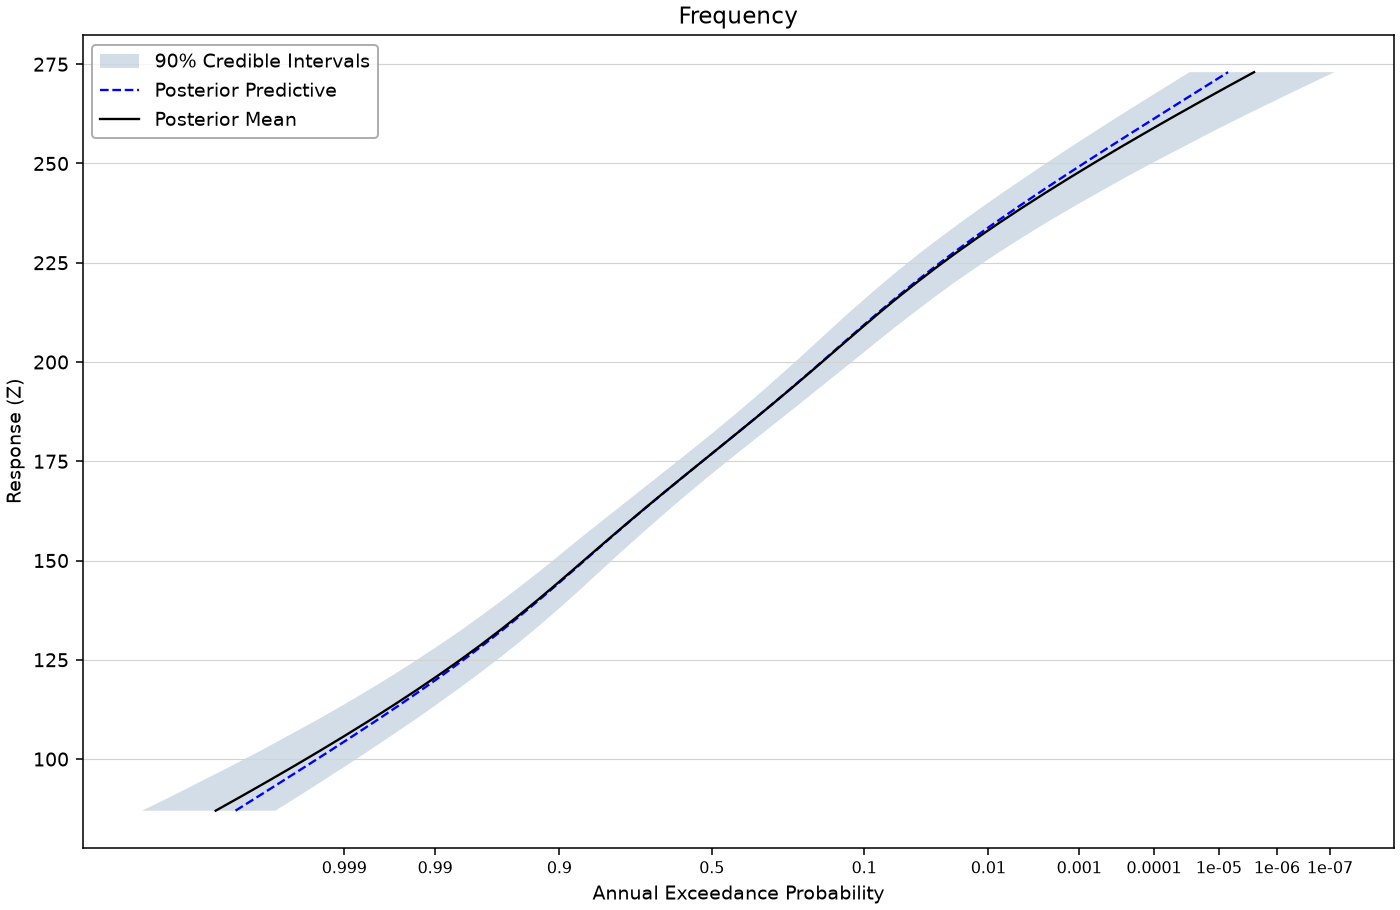

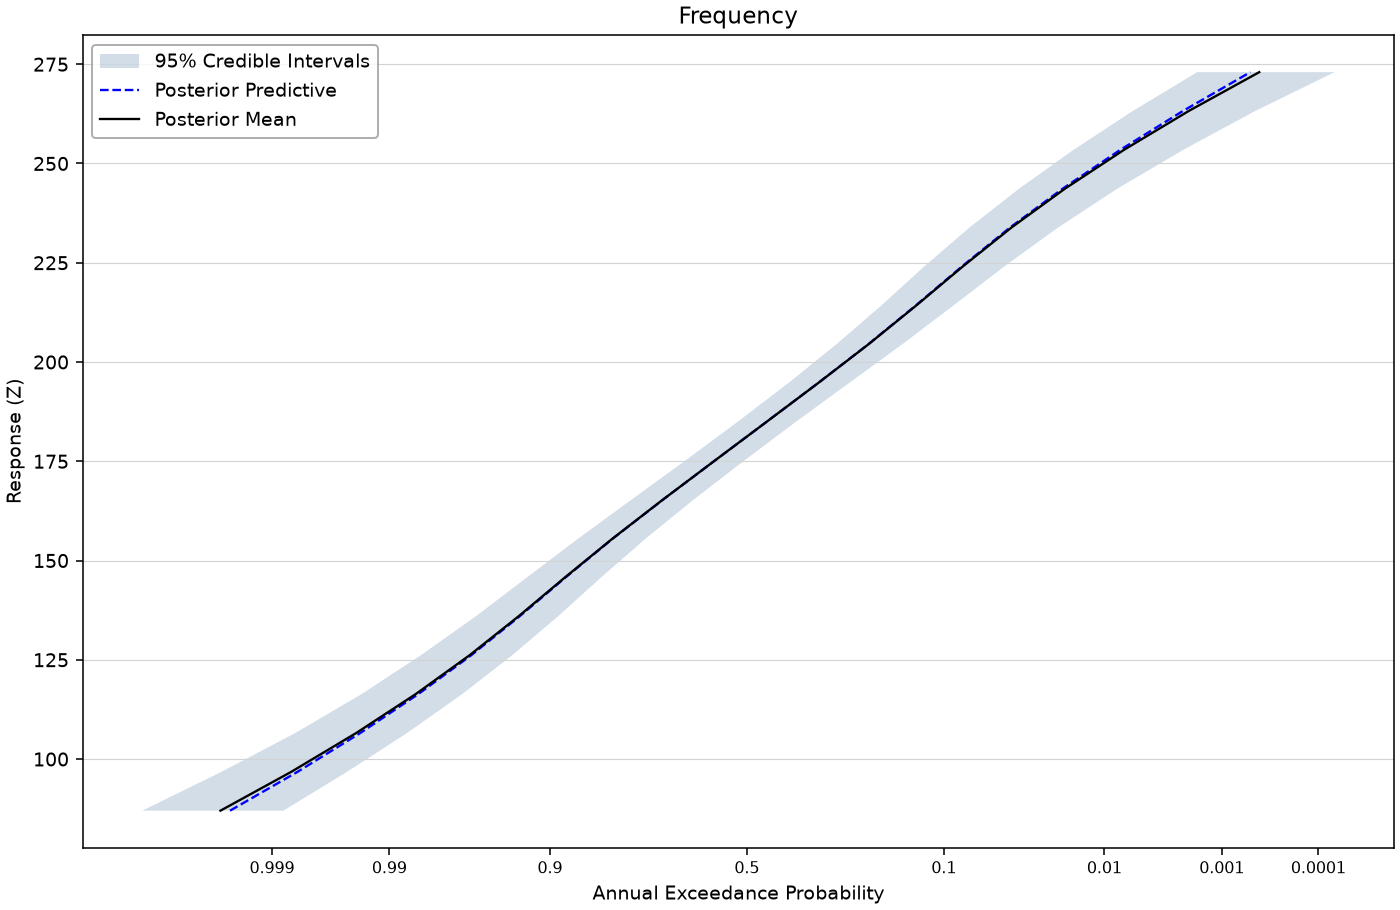

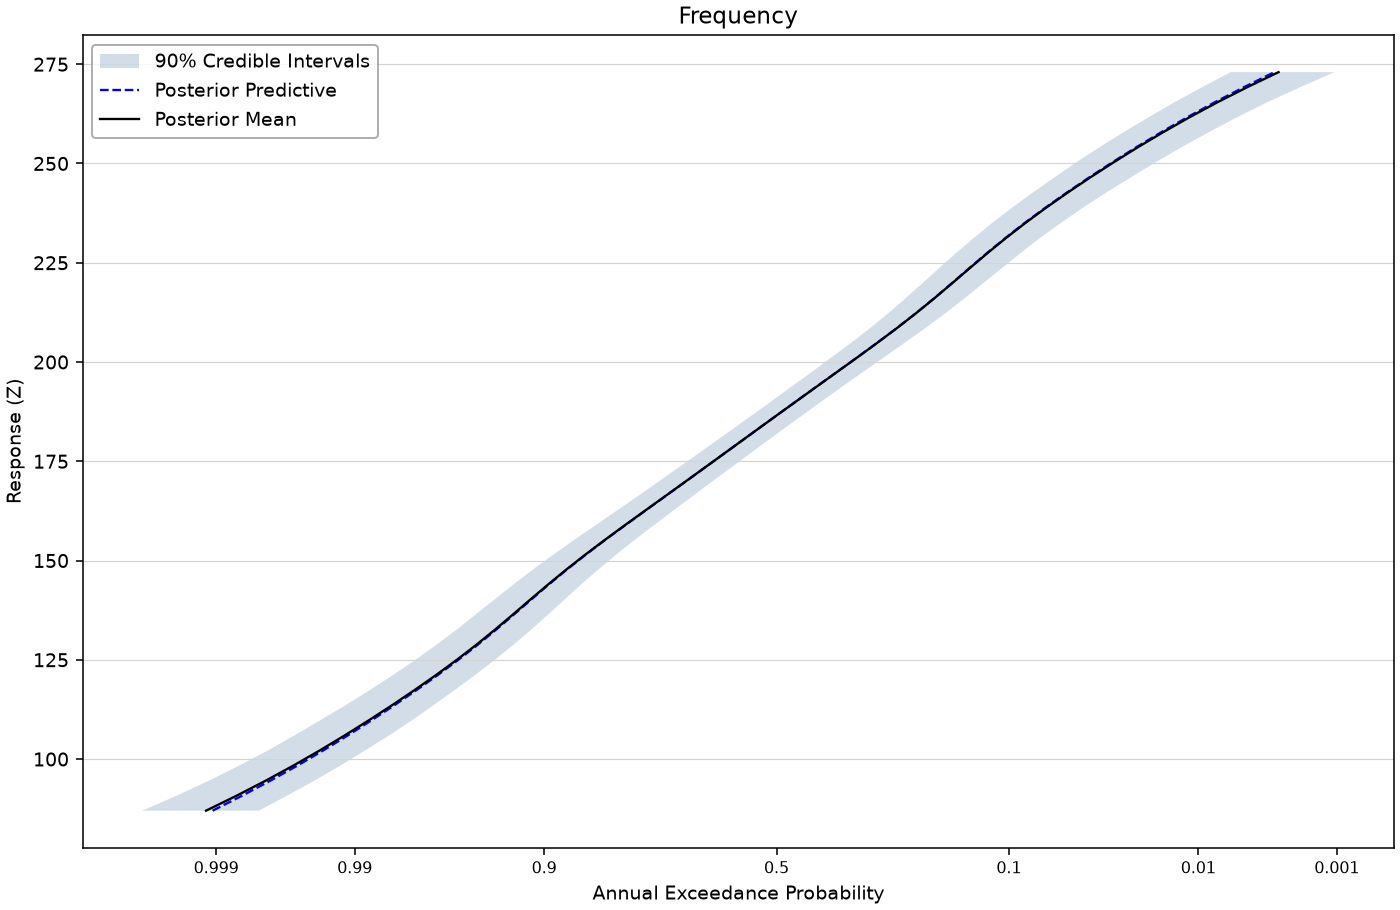

In [5]:
rows, sum_figures = [], {}
for cfa_name, rho, parent_name in sum_specs:
    cfa = sum_cfas[cfa_name]
    x_dist = sum_marginals[f"X Data - Rho = {rho}"].Distribution
    y_dist = sum_marginals[f"Y Data - Rho = {rho}"].Distribution
    rho_fit = float(sum_bivariates[parent_name].BayesianAnalysis.Results.PosteriorMean.Values[0])
    sigma = np.sqrt(float(x_dist.Sigma)**2 + float(y_dist.Sigma)**2 +
                    2*rho_fit*float(x_dist.Sigma)*float(y_dist.Sigma))
    truth = Normal(float(x_dist.Mu)+float(y_dist.Mu), float(sigma))
    z = np.array(list(cfa.ZOutputValues), dtype=float)
    aep = np.array(list(cfa.AnalysisResults.ModeCurve), dtype=float)
    error = np.abs(aep - np.array([1 - truth.CDF(float(v)) for v in z]))
    assert np.isfinite(error).all()
    assert error.max() <= .05 and error.mean() <= .01
    assert np.all(np.diff(aep) <= 1e-9)
    rows.append({"Case": cfa_name, "Fitted rho": rho_fit, "Bins": cfa.NumberOfBins,
                 "Maximum AEP error": error.max(), "Mean AEP error": error.mean()})
    sum_figures[cfa_name] = plots(plot_context(cfa, name=cfa_name, raw=sum_raw,
                                               dependencies={"bivariate": sum_bivariates[parent_name]}))
display(pd.DataFrame(rows))
for cfa_name, _, _ in sum_specs:
    # Compact labels keep the closely spaced rare-tail probability ticks readable.
    with plt.rc_context({"xtick.labelsize": 8}):
        show(sum_figures[cfa_name]["frequency"])

## Waimea/Makaweli conditional stage response

The Waimea peak input includes exact floods, low-outlier flags, and historical
perception thresholds. The Makaweli input consists of peaks conditional on Waimea
events; independently selected annual maxima would change the event population.
Waimea's regional-skew and three quantile priors are part of this case definition.

In [6]:
waimea_inputs = [
    ("16031000_Waimea_Peaks", "WaimeaPk - Exact + Historical + RR Prior_RSkew"),
    ("16036000_Makaweli_Conditional_Peaks", "MakaweliPk - Cond - Exact"),
]
waimea_frames, waimea_models, waimea_marginal_analyses = {}, {}, {}
for input_name, marginal_name in waimea_inputs:
    observed = waimea_raw["inputs"][input_name]
    frame = DataFrame()
    frame.ExactSeries = ExactSeries()
    for row in observed["series"]["ExactSeries"]:
        point = ExactData(DateTime.Parse(row["DateTime"]), float(row["Value"]))
        point.Index = int(row["Index"])
        point.IsLowOutlier = row.get("IsLowOutlier", "False") == "True"
        frame.ExactSeries.Add(point)
    for row in observed["series"]["ThresholdSeries"]:
        threshold = ThresholdData(int(row["StartIndex"]), int(row["EndIndex"]), float(row["Value"]))
        threshold.NumberAbove = int(row["NumberAbove"])
        frame.ThresholdSeries.Add(threshold)
    frame.LowOutlierThreshold = float(observed["attributes"]["LowOutlierThreshold"])
    frame.PlottingParameter = 0.0
    frame.SetLambda(float(observed["attributes"]["Lambda"]))
    assert frame.Lambda == 1.0
    frame.CalculatePlottingPositions()
    waimea_frames[input_name] = frame
    model = UnivariateDistribution(frame, UnivariateDistributionType.LogPearsonTypeIII)
    model.UseJeffreysRuleForScale = True
    if input_name == "16031000_Waimea_Peaks":
        model.UseDefaultFlatPriors = False
        model.Parameters[0].LowerBound, model.Parameters[0].UpperBound = -7.0, 7.0
        model.Parameters[0].PriorDistribution = Uniform(0.0, 6.0)
        model.Parameters[1].LowerBound, model.Parameters[1].UpperBound = 1.11022302462516e-16, 7.0
        model.Parameters[1].PriorDistribution = Uniform(1.11022302462516e-16, 2.0)
        model.Parameters[2].LowerBound, model.Parameters[2].UpperBound = -2.0, 2.0
        model.Parameters[2].PriorDistribution = Normal(-.157, .46)
        model.EnableQuantilePriors = True
        model.UseSingleQuantile = False
        quantile_priors = List[QuantilePrior]()
        quantile_priors.Add(QuantilePrior(.1, LogNormal(4.3234, .1758)))
        quantile_priors.Add(QuantilePrior(.01, LogNormal(4.6408, .163401346)))
        quantile_priors.Add(QuantilePrior(.002, LogNormal(4.8037, .1578)))
        model.QuantilePriors = quantile_priors
        chains, thinning, estimator = 6, 30, BayesianAnalysis.PointEstimateType.PosteriorMean
    else:
        model.UseDefaultFlatPriors = True
        # Conditional Makaweli's authored mean support starts at machine epsilon;
        # the fresh default on these observations starts at 2.
        model.Parameters[0].LowerBound = 1.11022302462516e-16
        model.Parameters[0].UpperBound = 5.0
        model.Parameters[0].IsPositive = True
        model.Parameters[0].PriorDistribution = Uniform(1.11022302462516e-16, 5.0)
        chains, thinning, estimator = 6, 30, BayesianAnalysis.PointEstimateType.PosteriorMean
    waimea_models[input_name] = model
    analysis = UnivariateAnalysis(model)
    analysis.Name = marginal_name
    bayes = analysis.BayesianAnalysis
    bayes.UseSimulationDefaults = True
    bayes.Type = BayesianAnalysis.SamplerType.DEMCzs
    bayes.NumberOfChains = chains
    bayes.ThinningInterval = thinning
    bayes.WarmupIterations = 1750
    bayes.Iterations = 3500
    bayes.PRNGSeed = 12345
    bayes.UseAdvancedSimulationDefaults = True
    bayes.InitialIterations = 300
    bayes.Jump = .971630931303994
    bayes.CredibleIntervalWidth = .9
    bayes.OutputLength = 10000
    bayes.PointEstimator = estimator
    started = perf_counter()
    analysis.RunAsync(None).GetAwaiter().GetResult()
    record_run(marginal_name, analysis, perf_counter() - started, raw=waimea_raw, model=model)
    waimea_marginal_analyses[marginal_name] = analysis

WaimeaPk - Exact + Historical + RR Prior_RSkew: completed in 12.68 s. Execution alone does not establish convergence or scientific acceptance.


MakaweliPk - Cond - Exact: completed in 2.96 s. Execution alone does not establish convergence or scientific acceptance.


## Estimate conditional dependence and propagate the stage surface

The 10×5 table is the source example's stage response in feet, not observed stage
data and not an invented sum of flows. CFA integrates that table under the fitted
distribution. Its posterior bands propagate the freshly estimated marginal and
copula chains, preserving the desktop example's uncertainty inputs.

Normal Copula - Conditional: completed in 9.30 s. Execution alone does not establish convergence or scientific acceptance.


CFA - Normal - Conditional: completed in 0.44 s. Execution alone does not establish convergence or scientific acceptance.


,X ordinates,Y ordinates,Response cells,Stage min (ft),Stage max (ft),Output bins
0,10,5,50,7.14,28.15,50


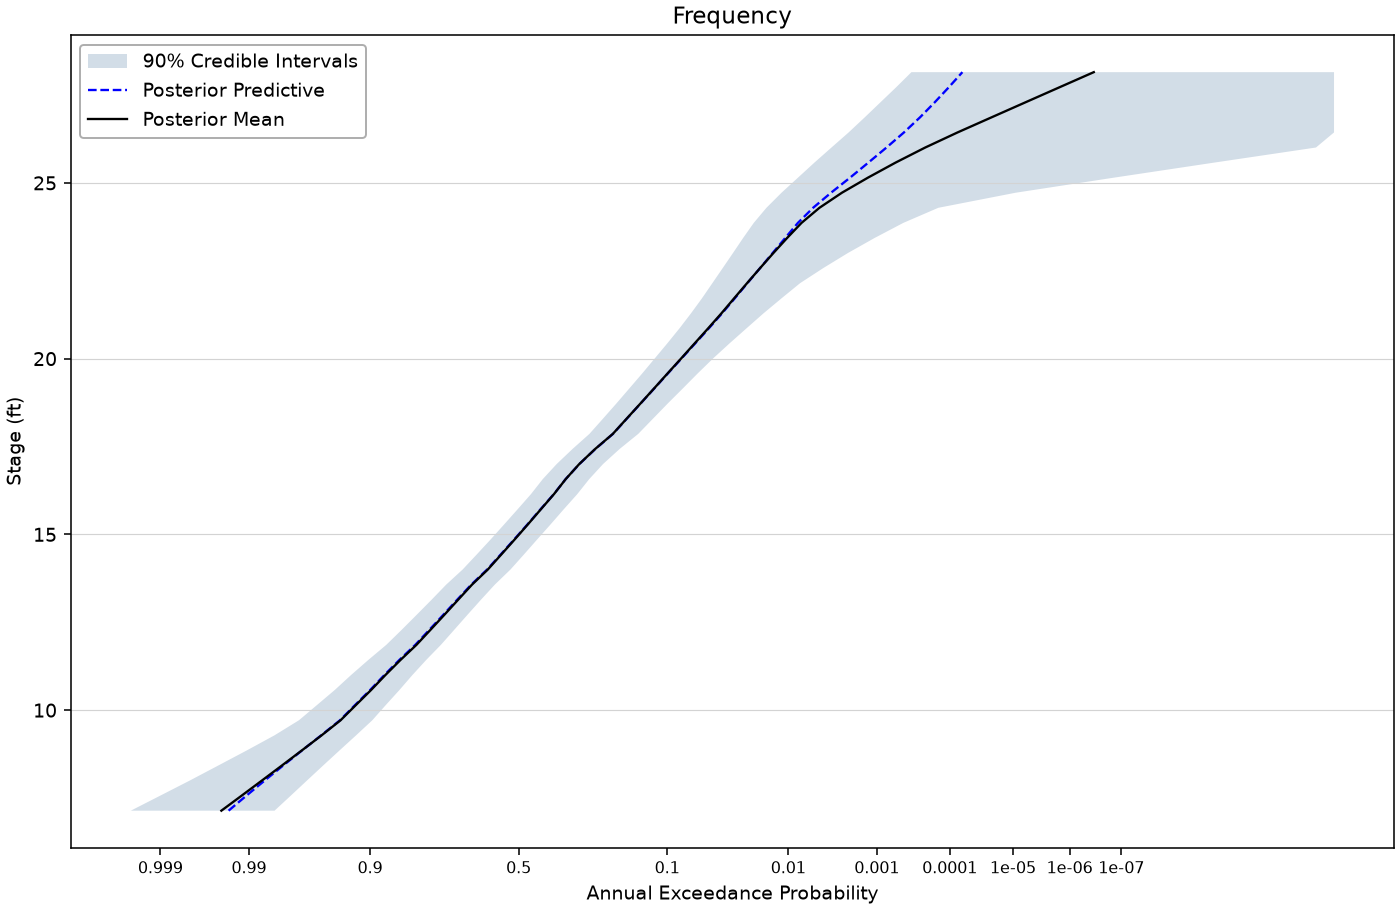

In [7]:
waimea_joint = BivariateDistribution(waimea_models["16031000_Waimea_Peaks"],
    waimea_models["16036000_Makaweli_Conditional_Peaks"], CopulaType.Normal)
waimea_joint.UseDefaultFlatPriors = True
waimea_bivariate = BivariateAnalysis(waimea_joint)
waimea_bivariate.Name = "Normal Copula - Conditional"
bayes = waimea_bivariate.BayesianAnalysis
bayes.UseSimulationDefaults = True
bayes.Type = BayesianAnalysis.SamplerType.DEMCzs
bayes.NumberOfChains = 4
bayes.ThinningInterval = 10
bayes.WarmupIterations = 1750
bayes.Iterations = 3500
bayes.PRNGSeed = 12345
bayes.UseAdvancedSimulationDefaults = True
bayes.InitialIterations = 100
bayes.Jump = 1.6829141392239828
bayes.CredibleIntervalWidth = .9
bayes.OutputLength = 10000
bayes.PointEstimator = BayesianAnalysis.PointEstimateType.PosteriorMean
started = perf_counter()
waimea_bivariate.RunAsync(None).GetAwaiter().GetResult()
record_run(waimea_bivariate.Name, waimea_bivariate, perf_counter() - started,
           raw=waimea_raw, model=waimea_joint)
surface = responses["waimea-river-stage-frequency"]["CFA - Normal - Conditional"]
assert surface["bivariate_analysis"] == waimea_bivariate.Name
assert (len(surface["x"]), len(surface["y"])) == (10, 5)
waimea_cfa = CoincidentFrequencyAnalysis(waimea_bivariate, Array[Double](surface["x"]),
    Array[Double](surface["y"]), net_matrix(surface["response"]))
waimea_cfa.Name = "CFA - Normal - Conditional"
waimea_cfa.NumberOfBins = surface["bins"]
waimea_cfa.BayesianAnalysis.CredibleIntervalWidth = .9
waimea_cfa.BayesianAnalysis.PointEstimator = BayesianAnalysis.PointEstimateType.PosteriorMean
waimea_cfa.MarginalXChain = waimea_marginal_analyses[
    "WaimeaPk - Exact + Historical + RR Prior_RSkew"].BayesianAnalysis.Results
waimea_cfa.MarginalYChain = waimea_marginal_analyses["MakaweliPk - Cond - Exact"].BayesianAnalysis.Results
assert Object.ReferenceEquals(waimea_cfa.MarginalXChain,
    waimea_marginal_analyses["WaimeaPk - Exact + Historical + RR Prior_RSkew"].BayesianAnalysis.Results)
assert Object.ReferenceEquals(waimea_cfa.MarginalYChain,
    waimea_marginal_analyses["MakaweliPk - Cond - Exact"].BayesianAnalysis.Results)
assert waimea_cfa.MarginalXChain.Output.Count == waimea_cfa.MarginalYChain.Output.Count == 10000
started = perf_counter()
waimea_cfa.RunAsync(None).GetAwaiter().GetResult()
record_run(waimea_cfa.Name, waimea_cfa, perf_counter() - started, raw=waimea_raw)
display(pd.DataFrame([{"X ordinates": len(surface["x"]), "Y ordinates": len(surface["y"]),
                       "Response cells": len(surface["x"])*len(surface["y"]),
                       "Stage min (ft)": min(map(min, surface["response"])),
                       "Stage max (ft)": max(map(max, surface["response"])),
                       "Output bins": waimea_cfa.NumberOfBins}]))
waimea_stage_plot = plots(plot_context(waimea_cfa, name=waimea_cfa.Name, raw=waimea_raw,
                                      dependencies={"bivariate": waimea_bivariate}))["frequency"]
waimea_stage_plot["axes"]["y"]["label"] = "Stage (ft)"
with plt.rc_context({"xtick.labelsize": 8}):
    show(waimea_stage_plot)

## Inspect the Bayesian dependencies

CFA propagates the copula and both marginal chains; it does not produce a new
fitted chain. The R-hat and effective sample size below
come from each fresh marginal and bivariate dependency. Values near 1 and
larger ESS support sampling quality but do not validate the event definition,
selected copula, or the externally specified response surface.

In [8]:
diagnostics = []
dependencies = {**sum_marginal_analyses, **sum_bivariates,
                **waimea_marginal_analyses,
                waimea_bivariate.Name: waimea_bivariate}
for analysis_name, dependency in dependencies.items():
    result = dependency.BayesianAnalysis.Results
    assert dependency.IsEstimated and result is not None
    for index, parameter in enumerate(result.ParameterResults):
        summary = parameter.SummaryStatistics
        diagnostics.append({"Analysis": analysis_name, "Coordinate": index + 1,
                            "R-hat": float(summary.Rhat), "ESS": float(summary.ESS),
                            "Lower 90%": float(summary.LowerCI), "Upper 90%": float(summary.UpperCI)})
display(pd.DataFrame(diagnostics))

,Analysis,Coordinate,R-hat,ESS,Lower 90%,Upper 90%
0,X Marginal - Rho = -0.5,1,0.999812,10058.343046,94.091325,99.249783
1,X Marginal - Rho = -0.5,2,0.999959,9768.773948,13.898803,17.547661
2,Y Marginal - Rho = -0.5,1,0.999849,10057.300247,75.694033,84.804960
3,Y Marginal - Rho = -0.5,2,0.999948,9278.078530,24.375177,30.786463
4,X Marginal - Rho = 0.0,1,1.000275,9321.432169,98.159919,103.099587
5,X Marginal - Rho = 0.0,2,1.000295,9343.243580,13.162026,16.604148
6,Y Marginal - Rho = 0.0,1,0.999651,8770.724955,76.611777,84.699781
7,Y Marginal - Rho = 0.0,2,1.000786,9559.676671,21.778327,27.484666
8,X Marginal - Rho = +0.5,1,1.000613,9609.624109,99.847070,104.698865
9,X Marginal - Rho = +0.5,2,1.000306,9437.088611,13.085404,16.540638


**Adapt this example:** supply matched X/Y observations and an increasing response
table on ascending ordinates, fit the marginals and copula, pass the marginal
results to `MarginalXChain`/`MarginalYChain`, then execute CFA.
The response model and conditional event definition need separate justification.